
#  Exploratory Data Analysis (EDA) on Game Sales Dataset
---
**Objective:**  
This notebook performs a professional exploratory data analysis (EDA) on a video game sales dataset.  
The goal is to understand the structure, relationships, and patterns in the dataset through data cleaning, visualization, and statistical summaries.


In [1]:

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# Configure visualization aesthetics
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [2]:

# Load the dataset
df = pd.read_csv('gamesalesfile.csv')

# Display basic dataset info
print("Dataset Loaded Successfully!")
display(df.head())

# Basic info
print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe(include='all'))


Dataset Loaded Successfully!


,Name,Platform,Year,Genre,Publisher,Developers,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,GTA V,PS4,2013,Action,Rockstar,Rockstar North,25.0,22.0,1.2,3.0,51.2
1,FIFA 21,PS5,2020,Sports,EA Sports,EA Canada,5.2,6.1,0.8,1.5,13.6
2,Call of Duty,Xbox,2019,Shooter,Activision,Infinity Ward,8.1,7.9,0.5,1.8,18.3
3,Minecraft,PC,2011,Sandbox,Mojang,Mojang Studios,12.3,8.5,0.3,2.1,23.2
4,The Witcher 3,PC,2015,RPG,CD Projekt,CD Projekt Red,4.5,5.0,0.4,1.0,10.9



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          10 non-null     object 
 1   Platform      10 non-null     object 
 2   Year          10 non-null     int64  
 3   Genre         10 non-null     object 
 4   Publisher     10 non-null     object 
 5   Developers    10 non-null     object 
 6   NA_Sales      10 non-null     float64
 7   EU_Sales      10 non-null     float64
 8   JP_Sales      10 non-null     float64
 9   Other_Sales   10 non-null     float64
 10  Global_Sales  10 non-null     float64
dtypes: float64(5), int64(1), object(5)
memory usage: 1012.0+ bytes

Statistical Summary:


,Name,Platform,Year,Genre,Publisher,Developers,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,10,10,10.000000,10,10,10,10.000000,10.000000,10.000000,10.000000,10.000000
unique,10,6,NaN,7,9,9,NaN,NaN,NaN,NaN,NaN
top,GTA V,PC,NaN,Shooter,CD Projekt,CD Projekt Red,NaN,NaN,NaN,NaN,NaN
freq,1,5,NaN,2,2,2,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2016.900000,NaN,NaN,NaN,8.960000,8.180000,1.000000,1.640000,19.780000
std,NaN,NaN,3.034981,NaN,NaN,NaN,6.346513,5.325369,1.612452,0.710555,12.750233
min,NaN,NaN,2011.000000,NaN,NaN,NaN,3.500000,3.200000,0.100000,0.800000,7.800000
25%,NaN,NaN,2015.500000,NaN,NaN,NaN,4.675000,5.275000,0.325000,1.050000,11.575000
50%,NaN,NaN,2017.500000,NaN,NaN,NaN,7.650000,7.350000,0.450000,1.600000,16.800000
75%,NaN,NaN,2019.000000,NaN,NaN,NaN,9.950000,8.475000,0.750000,2.025000,22.575000


In [3]:

# Check for missing and duplicate values
print("Missing Values per Column:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())


Missing Values per Column:
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
Developers      0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

Duplicate Rows: 0


In [4]:

# Handle missing values if any (fill numerical with mean, categorical with mode)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].mean(), inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("Data Cleaning Completed.")


Data Cleaning Completed.


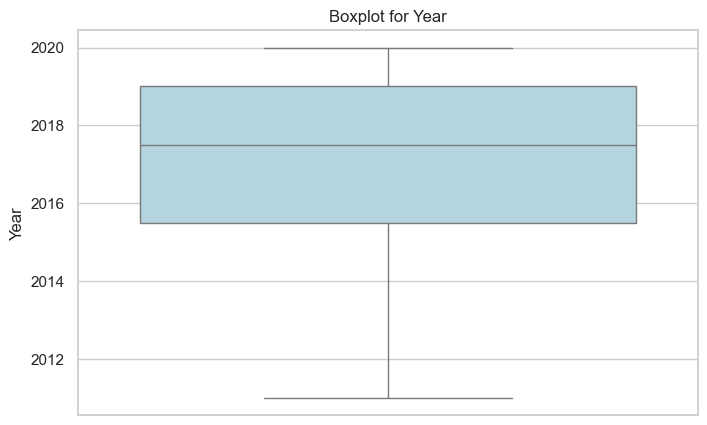

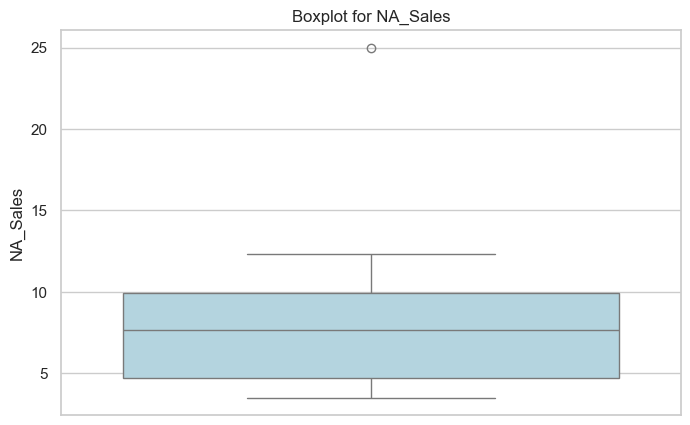

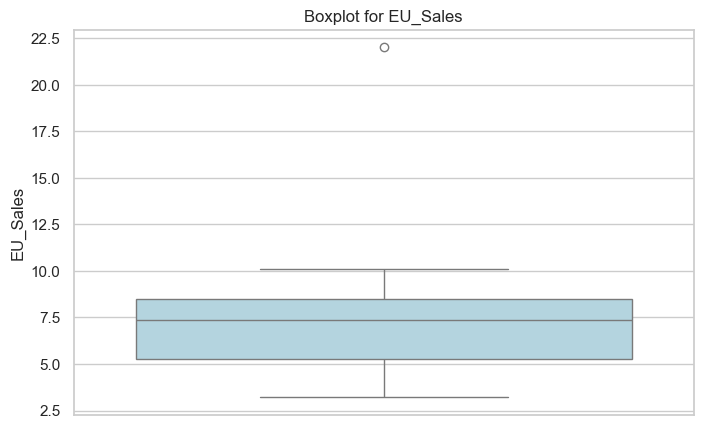

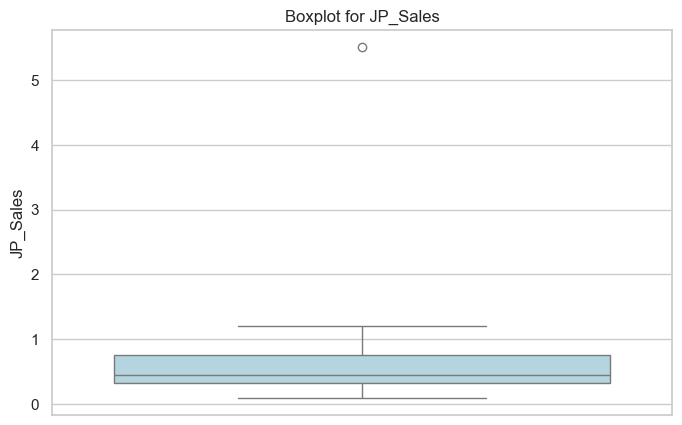

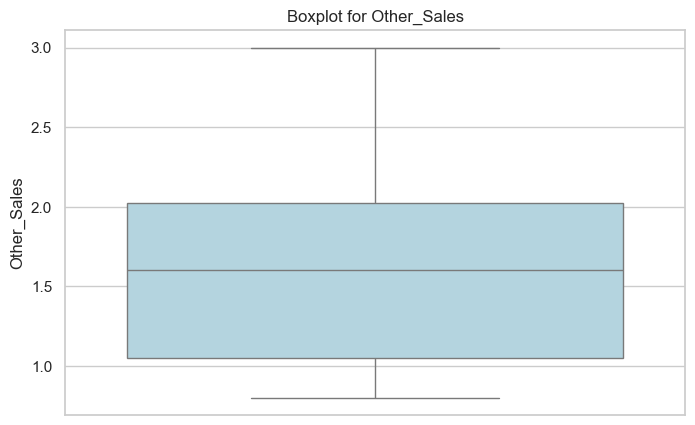

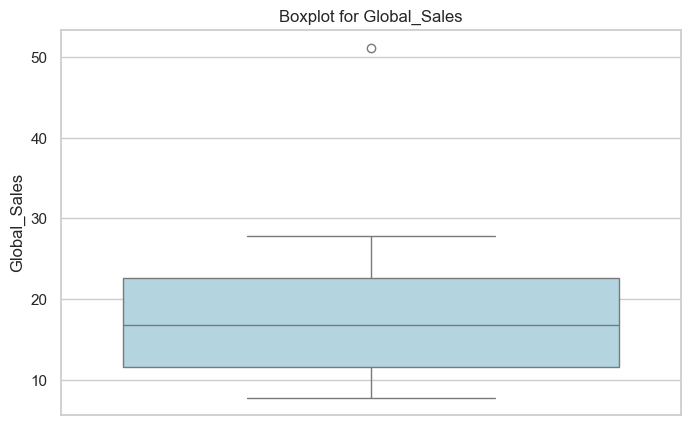

Total outliers detected: 0
Dataset shape after removing outliers: (10, 11)


In [5]:

# Visualize outliers using boxplots
for col in df.select_dtypes(include='number').columns:
    plt.figure()
    sns.boxplot(y=df[col], color='lightblue')
    plt.title(f"Boxplot for {col}")
    plt.show()

# Calculate z-scores for numeric columns
numeric_cols = df.select_dtypes(include='number').columns
z_scores = np.abs(zscore(df[numeric_cols]))

# Filter outliers
outliers = (z_scores > 3).any(axis=1)
print(f"Total outliers detected: {outliers.sum()}")

# Remove outliers if necessary
df_cleaned = df[~outliers]
print(f"Dataset shape after removing outliers: {df_cleaned.shape}")


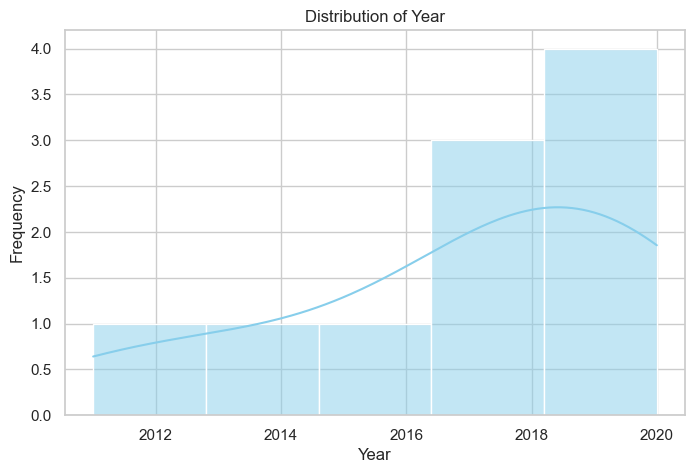

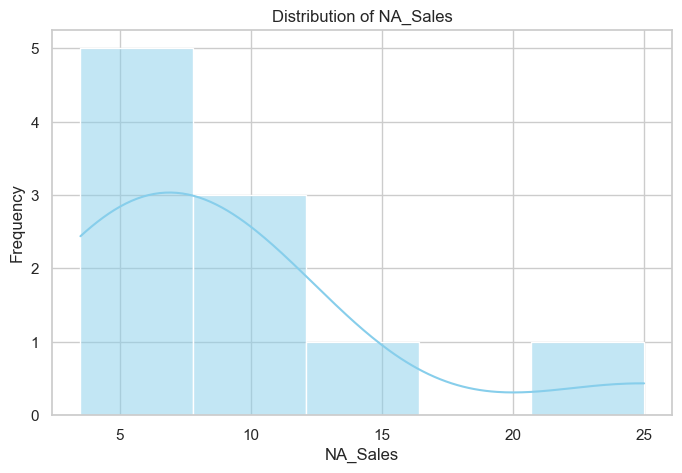

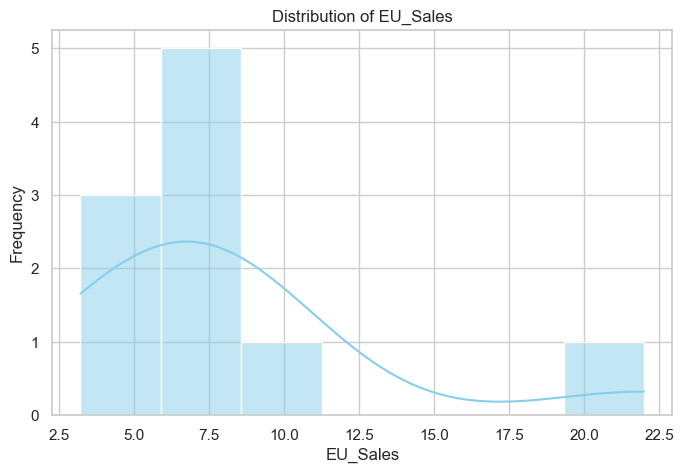

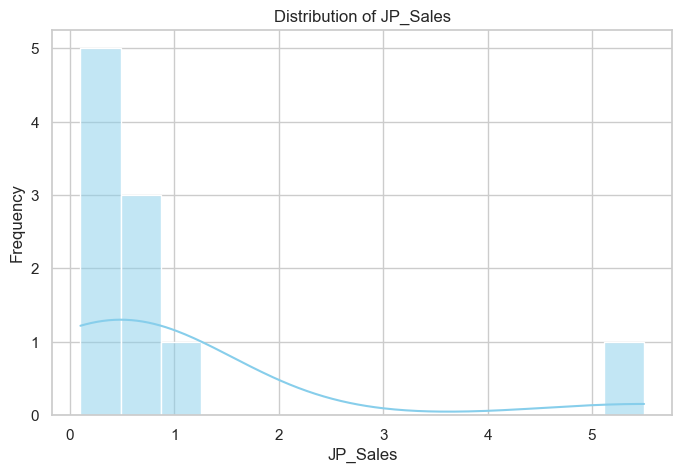

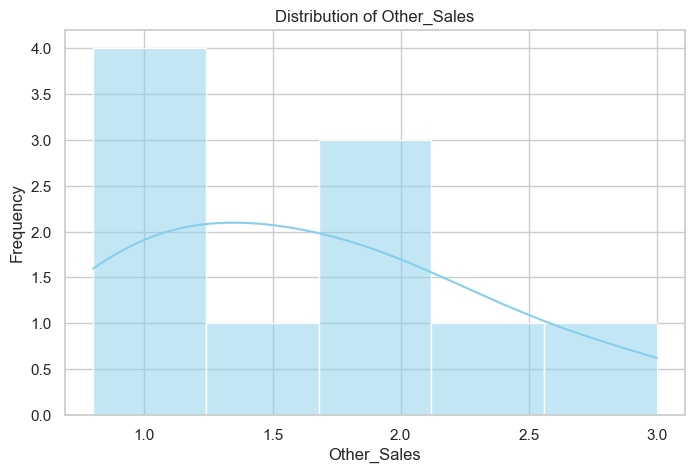

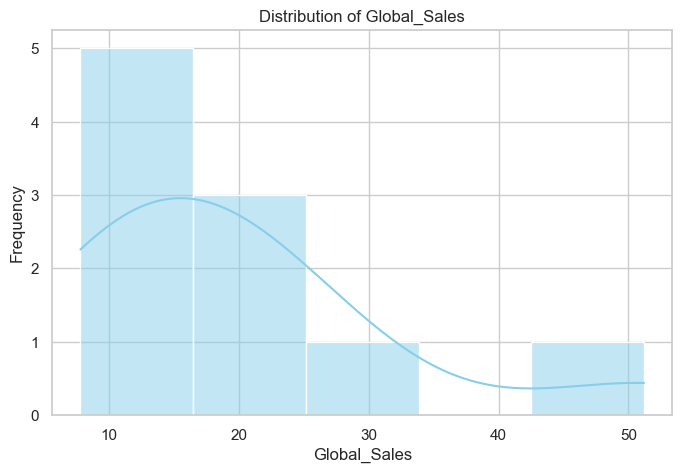

C:\Users\Admin\AppData\Local\Temp\ipykernel_16464\3408636156.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cleaned[col], palette='viridis')


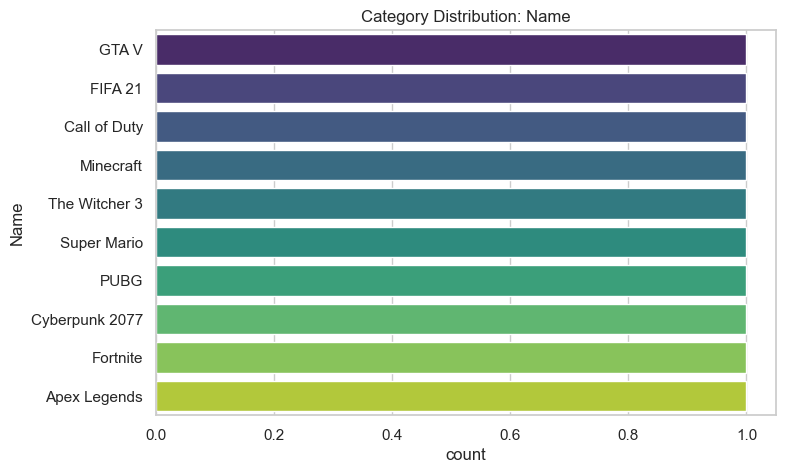

C:\Users\Admin\AppData\Local\Temp\ipykernel_16464\3408636156.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cleaned[col], palette='viridis')


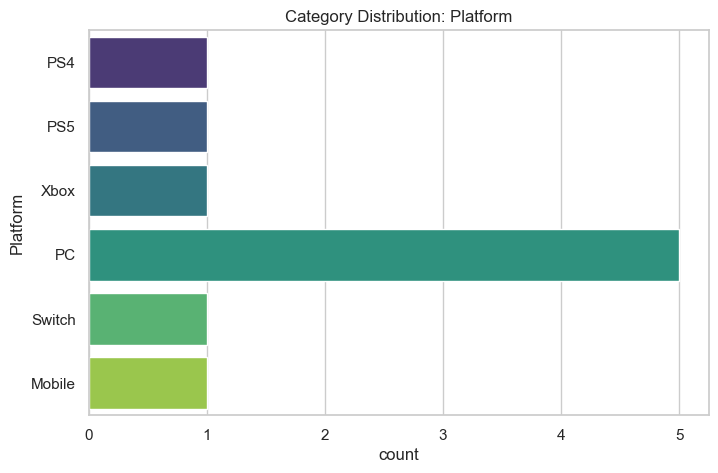

C:\Users\Admin\AppData\Local\Temp\ipykernel_16464\3408636156.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cleaned[col], palette='viridis')


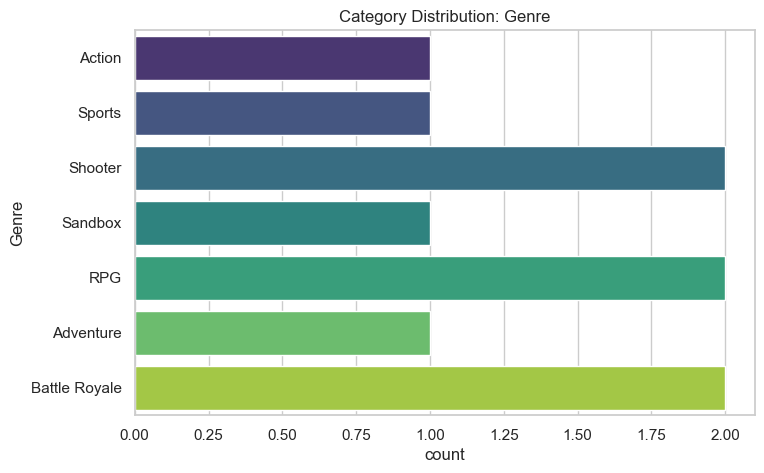

C:\Users\Admin\AppData\Local\Temp\ipykernel_16464\3408636156.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cleaned[col], palette='viridis')


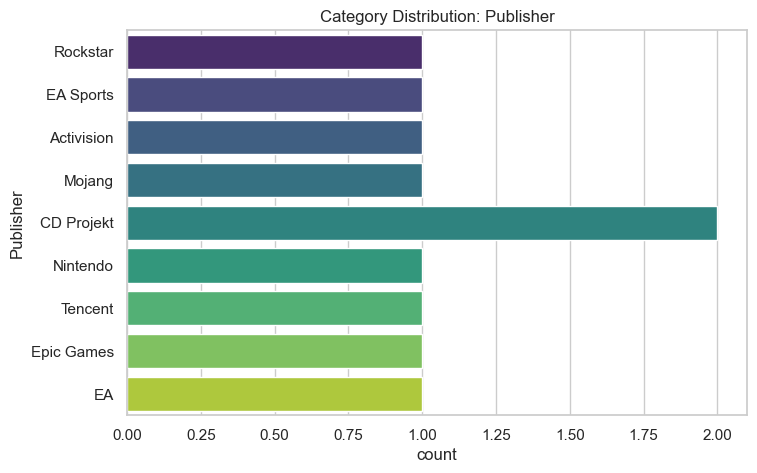

C:\Users\Admin\AppData\Local\Temp\ipykernel_16464\3408636156.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cleaned[col], palette='viridis')


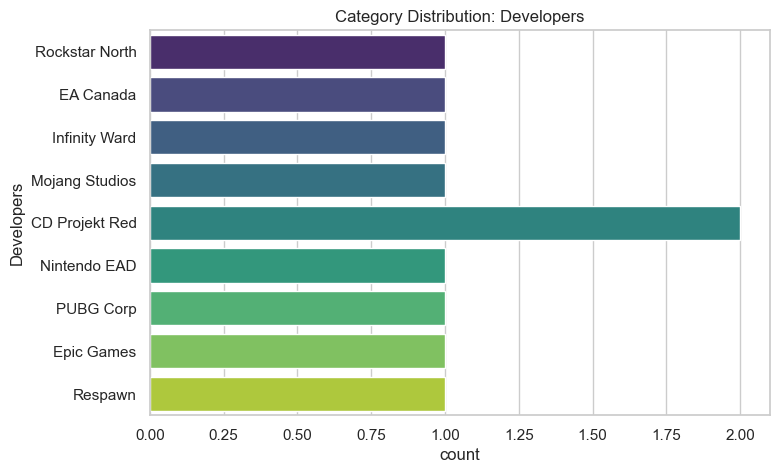

In [6]:

# Distribution of numerical features
for col in df_cleaned.select_dtypes(include='number').columns:
    plt.figure()
    sns.histplot(df_cleaned[col], kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# Countplots for categorical variables
for col in df_cleaned.select_dtypes(include='object').columns:
    plt.figure()
    sns.countplot(y=df_cleaned[col], palette='viridis')
    plt.title(f"Category Distribution: {col}")
    plt.show()


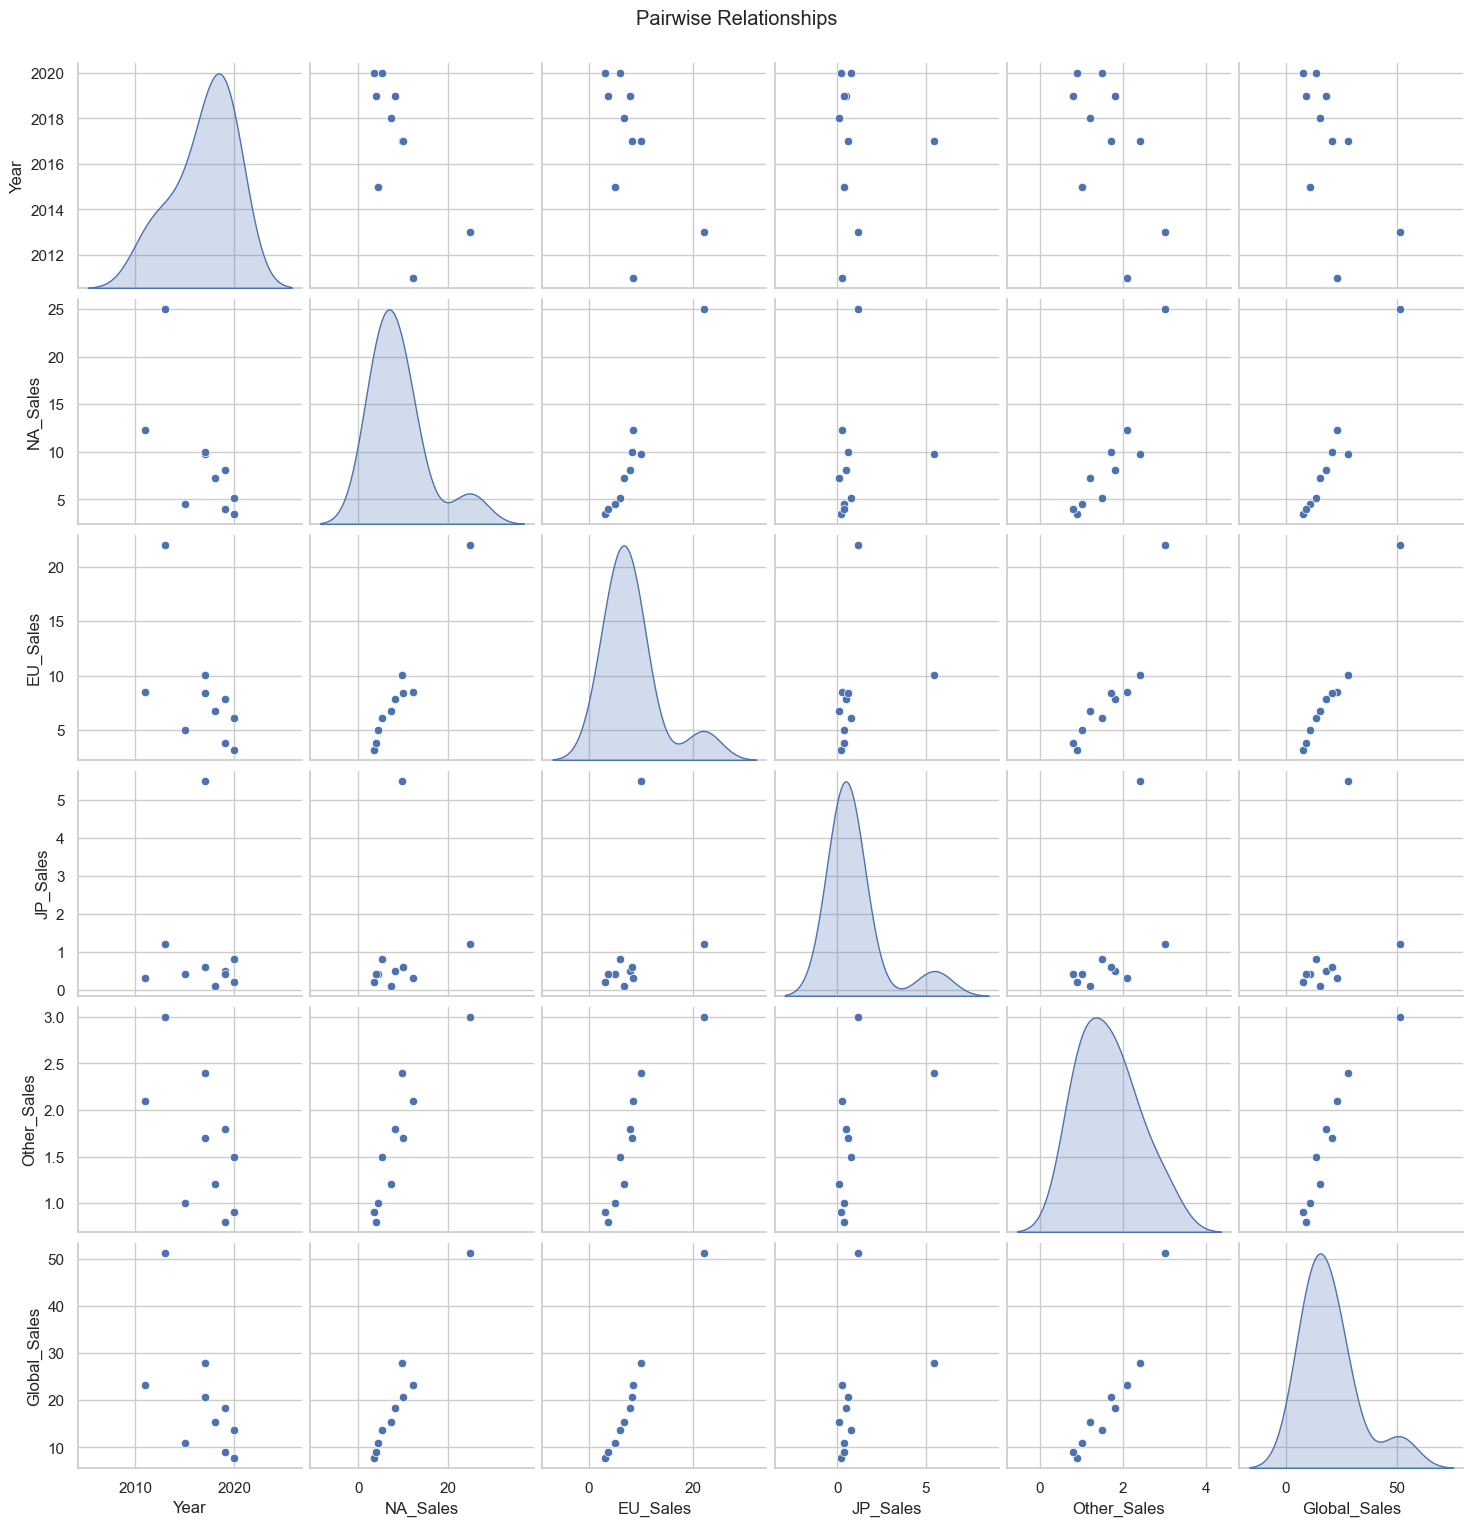

C:\Users\Admin\AppData\Local\Temp\ipykernel_16464\4252183768.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Platform', y='Global_Sales', data=df_cleaned, estimator=sum, palette='cool')


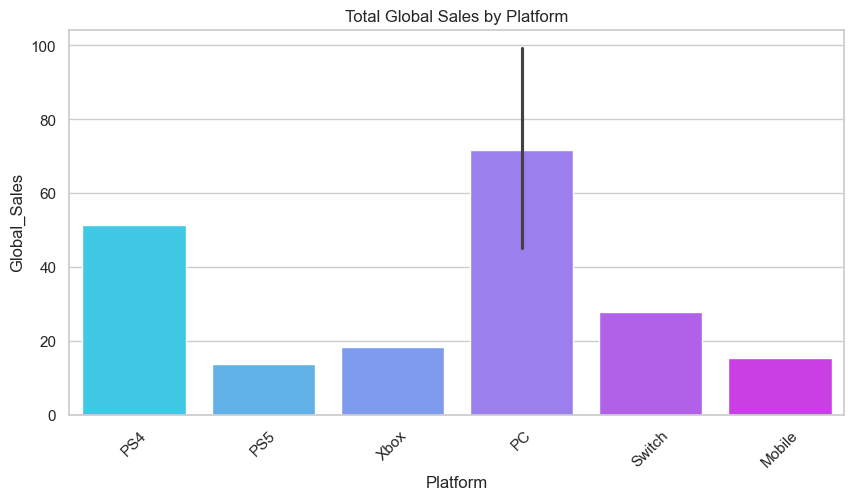

C:\Users\Admin\AppData\Local\Temp\ipykernel_16464\4252183768.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Genre', y='Global_Sales', data=df_cleaned, estimator=sum, palette='mako')


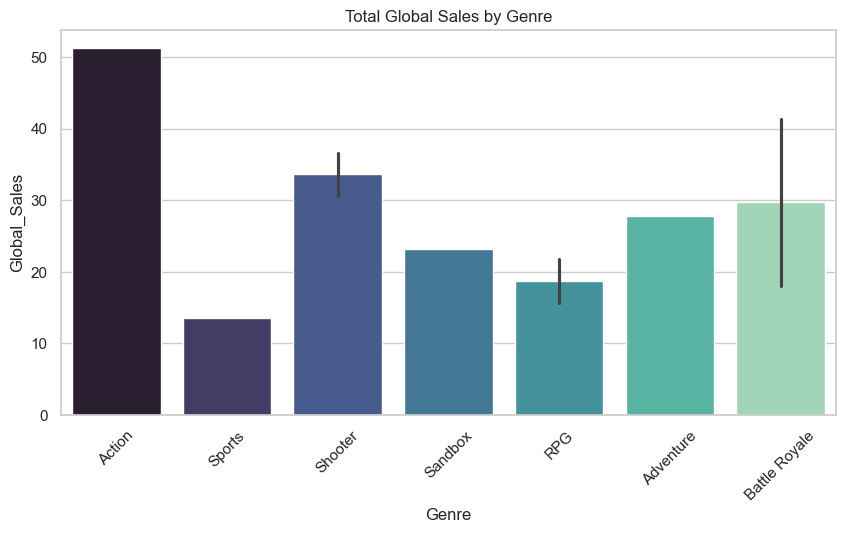

In [7]:

# Correlation between Global_Sales and other numeric columns
sns.pairplot(df_cleaned, diag_kind='kde')
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()

# Platform vs Global Sales
plt.figure(figsize=(10,5))
sns.barplot(x='Platform', y='Global_Sales', data=df_cleaned, estimator=sum, palette='cool')
plt.title("Total Global Sales by Platform")
plt.xticks(rotation=45)
plt.show()

# Genre vs Global Sales
plt.figure(figsize=(10,5))
sns.barplot(x='Genre', y='Global_Sales', data=df_cleaned, estimator=sum, palette='mako')
plt.title("Total Global Sales by Genre")
plt.xticks(rotation=45)
plt.show()


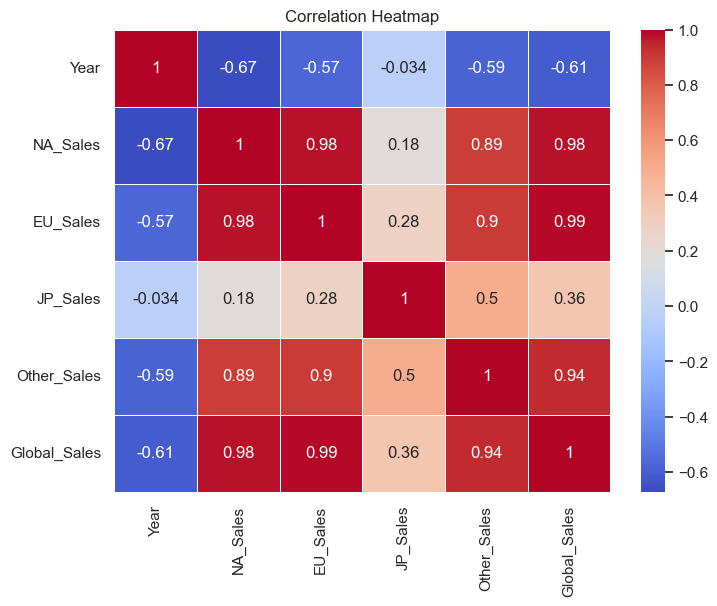

In [8]:

# Correlation heatmap for numerical features
corr_matrix = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()



##  Key Insights & Conclusion
---
- The dataset represents global video game sales across multiple platforms and genres.  
- Missing values were minimal and handled appropriately using mean/mode imputation.  
- Outlier detection was performed using z-scores to ensure data consistency.  
- Univariate and bivariate analyses helped identify which genres and platforms drive higher sales.  
- Correlation analysis shows moderate relationships between regional and global sales.  
